# Agentic Architecture 2: Tool Use

This notebook covers the second, and arguably one of the most transformative, agentic architectures: **Tool Use**. This pattern is the bridge that connects a Large Language Model's reasoning capabilities to the real, dynamic world.

Without tools, an LLM is a closed system, limited by the knowledge frozen into its training data. It cannot know today's weather, the current price of a stock, or the status of an order in your company's database. By giving an agent the ability to use tools, we empower it to overcome this fundamental limitation, allowing it to query APIs, search databases, and access live information to provide answers that are not just reasoned, but also factual, timely, and relevant.

### Definition

The **Tool Use** architecture equips an LLM-powered agent with the ability to call external functions or APIs (the "tools"). The agent autonomously decides when a user's query cannot be answered by its internal knowledge alone and determines which tool is appropriate to call to find the necessary information.

### High-level Workflow

1. **Receive Query:** The agent receives a request from the user.
2. **Decision:** The agent analyzes the query and its available tools. It decides if a tool is needed to answer the question accurately.
3. **Action:** If a tool is needed, the agent formats a call to that tool (e.g., a specific function with the right arguments).
4. **Observation:** The system executes the tool call, and the result (the "observation") is returned to the agent.
5. **Synthesis:** The agent integrates the tool's output into its reasoning process to generate a final, grounded answer for the user.

### When to Use / Applications

- **Research Assistants:** Answering questions that require up-to-the-minute information by using a web search API.
- **Enterprise Assistants:** Querying internal company databases to answer questions like *"How many new users signed up last week?"*
- **Scientific & Mathematical Tasks:** Using a calculator or a computational engine like WolframAlpha for precise calculations that LLMs often struggle with.

### Strengths & Weaknesses

- **Strengths:**
    - **Factual Grounding:** Drastically reduces hallucinations by fetching real, live data.
    - **Extensibility:** The agent's capabilities can be continuously expanded by simply adding new tools.
- **Weaknesses:**
    - **Integration Overhead:** Requires careful "plumbing" to define tools, handle API keys, and manage potential tool failures.
    - **Tool Trust:** The quality of the agent's answer is dependent on the reliability and accuracy of the tools it uses. The agent must trust that its tools provide correct information.




## Phase 0: Foundation & Setup

As before, we begin by setting up our environment. This includes installing the necessary libraries and configuring our API keys for OpenRouter, LangSmith, and the specific tool we will be using.

In [22]:
import os
import time
from typing import Annotated, TypedDict
from dotenv import load_dotenv

# Pydantic for data modeling / validation
from pydantic import BaseModel, Field

# LangChain components
from langchain_openrouter import ChatOpenRouter                     # OpenRouter LLM wrapper
from langchain_tavily import TavilySearch                           # Tavily search tool wrapper
from langchain_core.messages import HumanMessage                    # Standardized message format for interactions

# LangGraph components
from langgraph.graph import StateGraph, END                         # Build a state machine graph
from langgraph.graph.message import AnyMessage, add_messages        # For handling messages in the graph
from langgraph.prebuilt import ToolNode                             # Prebuilt nodes and conditions

# For pretty printing 
from rich.console import Console      


# --- API Key and Tracing Setup ---
load_dotenv()  

# Enable LangSmith tracing for monitoring and debugging
os.environ["LANGSMITH_PROJECT"] = "Agentic Architecture - Tool Use (OpenRouter)"

# Verify that all required API keys are available
for key in ["OPENROUTER_API_KEY", "LANGSMITH_API_KEY", "TAVILY_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and everything is set up.")

Environment variables loaded and everything is set up.


## Phase 1: Defining the Agent's Toolkit

An agent is only as capable as the tools it has access to. In this phase, we will define and test the specific tool we'll give our agent: `a live web search`.


### Step 1.1: The Problem

Large Language Models are trained on static datasets with a fixed knowledge cutoff. This means they are fundamentally unable to answer questions about real-time or recent information — such as current prices, live news, or today's events. When asked, they either hallucinate plausible-sounding but incorrect details, or openly admit they don't know. Neither is acceptable in a production system.

In [43]:
llm = ChatOpenRouter(
    model="nvidia/nemotron-3-super-120b-a12b:free", 
    temperature=0
)

console = Console()

test_query = "Today's date?"

In [44]:
# --- LLM Limitation (No Tool) ---

console.print("\n[bold red]--- LLM Without Tool ---[/bold red]")
console.print("[yellow]Querying LLM directly without any tool access...[/yellow]\n")

raw_response = llm.invoke([HumanMessage(content=test_query)])

console.print(f"[bold green]Query:[/bold green] {test_query}")
console.print(f"\n[bold red]LLM Response (No Tool):[/bold red]")
console.print(raw_response.content)

--- LLM Without Tool ---

Querying LLM directly without any tool access...

Query: Today's date?

LLM Response (No Tool):

I don't have real-time capabilities or access to the current date. My knowledge is current up to **July 2024**, and
I cannot retrieve live information like today's exact date.

For the most accurate and current date, I recommend checking:
- Your device's clock (phone, computer, etc.)
- A trusted website like (https://time.gov) (US) or (https://www.worldtimebuddy.com)
- A search engine query for "today's date"

Is there anything else I can help you with using my existing knowledge? 😊

**Discussion of the Output:**

The LLM admits it doesn't know — because it has no access to real-time data. It could hallucinate or provide outdated information as well. This is exactly why Tool Use matters. We need to bind the LLM with a search tool to fix this.

### Step 1.2: Creating and Testing the Web Search Tool

To overcome this limitation, we equip the LLM with a web search tool — giving it the ability to retrieve live, external information on demand. 

We will instantiate the `TavilySearch` tool. The most critical part of defining a tool is its **description**. The LLM uses this natural language description to understand what the tool does and when it should be used. A clear, precise description is essential for the agent to make correct decisions. We will then test the tool directly to see what its raw output looks like.

In [45]:
# --- Tool Setup ---
search_tool = TavilySearch(
    max_results=2,
    search_depth="advanced",   
    include_answer=True       
)
search_tool.name = "web_search"
search_tool.description = "A tool that can be used to search the internet for up-to-date information on any topic, including news, events, and current affairs."
tools = [search_tool]
print(f"Tool '{search_tool.name}' created with description: '{search_tool.description}'")

Tool 'web_search' created with description: 'A tool that can be used to search the internet for up-to-date information on any topic, including news, events, and current affairs.'


In [46]:
# --- Test the tool directly ---
print("\n--- Testing the tool directly ---")
test_result = search_tool.invoke({"query": test_query})
console.print(f"[bold green]Query:[/bold green] {test_query}")
console.print("\n[bold green]Result:[/bold green]")
console.print(test_result)


--- Testing the tool directly ---


Query: Today's date?

Result:

{
    'query': "Today's date?",
    'follow_up_questions': None,
    'answer': 'Today is Tuesday, May 20, 2026, in the Hong Kong time zone. It is the 140th day of the year, and the
season is spring.',
    'images': [],
    'results': [
        {
            'url': 'https://www.calendardate.com/todays.htm',
            'title': "Today's Date",
            'content': "# Today's Date\n\nToday's Date is Wednesday May 20, 2026\n\nTime zone: Hong Kong/Hong 
Kong\n\n|  |  |  |  |  |  |  |  |  |\n ---  ---  ---  --- \n| May 2026 | | | | | | | | |\n| Sun | Mon | Tue | Wed |
Thr | Fri | Sat |\n|  |  |  |  |  | 1 | 2 || 3 | 4 | 5 | 6 | 7 | 8 | 9 || 10 | 11 | 12 | 13 | 14 | 15 | 16 || 17 | 
18 | 19 | 20 | 21 | 22 | 23 || 24 | 25 | 26 | 27 | 28 | 29 | 30 || 31 |  |  |  |  |  |  |\n\n|  |  |\n --- |\n| Day
Number of Year: | 140 |\n| Week Number of Year: | 21 |\n| Month Number of Year: | 5 |\n| Leap Year: | No - Next is 
2028 |\n| Daylight Saving Time: | No | [...] |  |  |\n --- |\n| Today's Date in Other Date Formats | |\n| Unix 
Epoch: | 1779252103 |\n| ISO-8601: | 2026-05-20T12:41:43+08:00 |\n| RFC 2822: | Wed, 20 May 2026 12:41:43 +0800 
|\n| DD-MM-YYYY: | 20-05-2026 |\n| MM-DD-YYYY: | 05-20-2026 |\n| YYYY-DD-MM: | 2026-20-05 |\n| YYYY-MM-DD: | 
2026-05-20 |\n\n|  |  |\n --- |\n| Sun Today | |\n| Sunrise: | 5:41 am |\n| Sunset: | 6:58 pm |\n\n|  |  |\n --- 
|\n| Moon Today | |\n| Moonrise: | 8:42 am |\n| Moonset: | 10:51 pm |\n| Moonphase: | Waxing Crescent |\n| 
Visibility (illumination): | 13% |\n\n|  |  |\n --- |\n| Current Season Today | |\n| Spring with 32 days until the 
start of Summer. |\n| S. Hemishpere flip seasons - i.e. Winter is Summer. | [...] |  |  |\n --- |\n| Zodiac Signs 
and Birthday Symbols for Today's Date | |\n| Zodiac Sign: | Taurus |\n| Birthstone: | Emerald |\n| Birth Flower: | 
Lily of the Valley |\n\nUpcoming Holidays\n\n|  |  |  |\n --- \n| May 22 - Fri | National Maritime Day 2026 | 
Observance |\n| May 22 - Fri | Shavuot 2026 | Jewish |\n| May 24 - Sun | Pentecost 2026 | Christian |\n| May 25 - 
Mon | Memorial Day 2026 | Federal Holiday |\n| May 26 - Tues | Day of Arafat 2026 | Muslim |\n| May 27 - Wed | Eid 
al-Adha 2026 | Muslim |\n| Jun 4 - Tues | Corpus Christi 2026 | Christian |\n\nWe use cookies to personalize 
content, ads, and provide social media interaction and analyze traffic on our site. By using our site you consent 
to our Privacy Policy.\n\n© 2026 www.calendardate.com. All rights reserved.",
            'score': 0.98926485,
            'raw_content': None
        },
        {
            'url': 'https://www.calendar-365.com/calendar/2026/May.html',
            'title': 'May 2026 Calendar',
            'content': "| May 18, 2026 | 5:36 | 20:09 | 14h 33m |\n| May 19, 2026 | 5:36 | 20:10 | 14h 34m |\n| May
20, 2026 | 5:35 | 20:11 | 14h 36m |\n| May 21, 2026 | 5:34 | 20:12 | 14h 38m |\n| May 22, 2026 | 5:33 | 20:13 | 14h
40m |\n| May 23, 2026 | 5:32 | 20:13 | 14h 41m |\n| May 24, 2026 | 5:32 | 20:14 | 14h 42m |\n| May 25, 2026 | 5:31 
| 20:15 | 14h 44m |\n| May 26, 2026 | 5:30 | 20:16 | 14h 46m |\n| May 27, 2026 | 5:30 | 20:17 | 14h 47m |\n| May 
28, 2026 | 5:29 | 20:18 | 14h 49m |\n| May 29, 2026 | 5:29 | 20:19 | 14h 50m |\n| May 30, 2026 | 5:28 | 20:19 | 14h
51m |\n| May 31, 2026 | 5:28 | 20:20 | 14h 52m | [...] # May 2026 Calendar\n\nMay 2026\n\n| Week | Su | Mo | Tu | 
We | Th | Fr | Sa |\n ---  ---  ---  --- |\n| 18 |  | | | | | 1 | 2 |\n| 19 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |\n| 20 | 
10 | 11 | 12 | 13 | 14 | 15 | 16 |\n| 21 | 17 | 18 | 19 | 20 | 21 | 22 | 23 |\n| 22 | 24 | 25 | 26 | 27 | 28 | 29 |
30 |\n| 23 | 31 |  | | | | | |\n\n|  |  |\n --- |\n| May 5 | Cinco de Mayo |\n| May 10 | Mother's Day |\n| May 16 |
Armed Forces Day |\n| May 24 | Pentecost |\n| May 25 | Memorial Day & Pentecost Monday | [...] | Date | Sunrise | 
Sunset | Length of day |\n ---  --- |\n| May 1, 2026 | 5:55 | 19:52 | 13h 57m |\n| May 2, 2026 | 5:54 | 19:53 | 13h
59m |\n| May 3, 2026 | 5:52 | 19:54 | 14h 2m |\n| May 4, 2

**Discussion of the Output:** 

The test shows the raw output of our `web_search` tool. It returns a list of dictionaries, where each dictionary contains the URL and content snippet of a search result. This structured information is exactly what the agent will receive as its "observation" after it decides to use the tool. Now that we have a functional tool, we can build the agent that will learn how to use it.

## Phase 2: Building the Tool-Using Agent with LangGraph

Now we will construct the agentic workflow. This involves making the LLM aware of the tools and creating a graph that allows it to loop through a "think-act-observe" cycle, which is the essence of tool use.

### Step 2.1: Binding the Tools to the LLM

This is the critical step where we make the LLM "aware" of the tools. We use the `.bind_tools()` method, which passes the names and descriptions of our tools to the LLM's system prompt. This allows the model's internal logic to decide when to call a tool based on its description.


In [47]:
# --- Bind Tools ---

llm_with_tools = llm.bind_tools(tools)
print("LLM has been bound with the provided tools.")

LLM has been bound with the provided tools.


### Step 2.2: Defining the Graph State

The state for a tool-using agent is typically a list of messages that represents the conversation history. This history includes the user's questions, the agent's thoughts and tool calls, and the results from those tools. We will use a `TypedDict` that can hold any type of LangChain message.

In [48]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

print("AgentState TypedDict defined to manage conversation history.")

AgentState TypedDict defined to manage conversation history.


### Step 2.3: Defining the Agent Nodes

Our graph will have three nodes:

1. **`agent_node`**: The "brain". It calls the LLM with the current conversation history and decides whether a tool is needed. If yes, it emits a tool call request. If no, it answers directly.
2. **`tool_node`**: The "hands". It takes the tool call request from `agent_node`, executes the web search, and returns the raw result back into the message history.
3. **`responder_node`**: The "voice". It receives the full message history — including the raw tool result — and generates a clean, polished final answer for the user. This ensures the output is never a raw JSON dump from the search tool.

In [49]:
def agent_node(state: AgentState):
    """The primary node that calls the LLM to decide the next action."""
    console.print("--- AGENT: Thinking... ---")

    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }

# The ToolNode is a pre-built node from LangGraph that executes tools
tool_node = ToolNode(tools)

def responder_node(state: AgentState):
    """Takes the tool result and generates a clean final answer."""
    console.print("\n[bold cyan]--- RESPONDER: Generating final answer... ---[/bold cyan]")
    response = llm_with_tools.invoke(state["messages"])
    return {
        "messages": [response]
    }

print("Agent node, Tool node, and Responder node have been defined.")

Agent node, Tool node, and Responder node have been defined.


### Step 2.4: Defining the Conditional Router

After the `agent_node` runs, we need to decide where to go next. The router function inspects the last message from the agent. If that message contains a `tool_calls` attribute, it means the agent wants to use a tool, so we route to the `tool_node`. If not, it means the agent has a final answer, and we can end the workflow.

In [50]:
def router_function(state: AgentState):
    """After agent responds, either call the tool ONCE or end."""
    last_message = state["messages"][-1]
    console.print(f"[yellow]Router: {type(last_message).__name__}, tool_calls={getattr(last_message, 'tool_calls', None)}[/yellow]")
    if last_message.tool_calls:
        return "call_tool"
    return "__end__"

print("Router function defined.")

Router function defined.



## Phase 3: Assembling and Running the Workflow

Now we'll wire all the components together into a complete, executable graph and run it on a query that forces the agent to use its new web search capability.


### Step 3.1: Building and Visualizing the Graph

We will create the `StateGraph` and add our nodes and edges. The key part is the conditional edge 
that uses our `router_function` to direct the flow: if the agent requests a tool, it goes to 
`call_tool`, which then passes the result to `responder` for a final polished answer. If no tool 
is needed, the agent answers directly and the graph ends: `agent -> call_tool -> responder -> end`.

Tool-using agent graph compiled successfully!


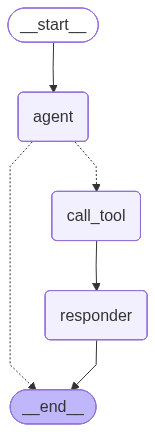

In [51]:
# --- Graph ---
# Flow: start → agent → (has tool call?) → call_tool → responder → end
#                     ↓ no
#                    end

graph_builder = StateGraph(AgentState)

graph_builder.add_node("agent", agent_node)
graph_builder.add_node("call_tool", tool_node)
graph_builder.add_node("responder", responder_node)

graph_builder.set_entry_point("agent")

graph_builder.add_conditional_edges(
    "agent",
    router_function,
    {
        "call_tool": "call_tool",
        "__end__": END
    }
)

# call_tool goes directly to END — no loop back to agent
graph_builder.add_edge("call_tool", "responder")
graph_builder.add_edge("responder", END) 

tool_agent_app = graph_builder.compile()
print("Tool-using agent graph compiled successfully!")

# --- Visualize ---
try:
    from IPython.display import Image, display
    display(Image(tool_agent_app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization failed. Please ensure graphviz is installed.")


**Discussion of the Output:**

The compiled graph is ready. The visualization clearly shows the agent's linear flow. The process 
starts at the `agent` node. The conditional edge (represented by the dashed lines) then routes the 
flow. If a tool is needed, it goes to `call_tool`, whose output is passed to the `responder` node 
for a clean, polished final answer. If no tool is needed, the agent answers directly and the 
process goes to `__end__`. This structure perfectly implements the Basic Tool Use pattern — a 
single, one-shot tool call with no loop.

### Step 3.2: End-to-End Execution

Let's run the agent with a question that it cannot possibly know from its training data, forcing it to use the web search tool. We will stream the intermediate steps to watch its reasoning process unfold.


In [53]:
# --- Run ---
initial_input = {"messages": [HumanMessage(content=test_query)]}

console.print(f"\n[bold cyan]🚀 Kicking off Tool Use workflow for:[/bold cyan] '{test_query}'\n")

for state in tool_agent_app.stream(initial_input, stream_mode="values"):
    state["messages"][-1].pretty_print()

console.print("\n[bold green]✅ Tool Use workflow complete![/bold green]")

🚀 Kicking off Tool Use workflow for: 'Today's date?'

================================ Human Message =================================

Today's date?


--- AGENT: Thinking... ---

Router: AIMessage, tool_calls=[{'name': 'web_search', 'args': {'query': "today's date", 'search_depth': 'fast'}, 
'id': 'chatcmpl-tool-90e57920790625f8', 'type': 'tool_call'}]

================================== Ai Message ==================================
Tool Calls:
  web_search (chatcmpl-tool-90e57920790625f8)
 Call ID: chatcmpl-tool-90e57920790625f8
  Args:
    query: today's date
    search_depth: fast
================================= Tool Message =================================
Name: web_search

{"query": "today's date", "follow_up_questions": null, "answer": "Today is Tuesday, May 19, 2026, and it is the 139th day of the year. It is currently spring in the Southern Hemisphere.", "images": [], "results": [{"url": "https://www.calendardate.com/todays.htm", "title": "Today's Date", "content": "# Today's Date\n\nToday's Date is Tuesday May 19, 2026\n\nTime zone: California/San Francisco\n\n|  |  |  |  |  |  |  |  |  |\n ---  ---  ---  --- \n| May 2026 | | | | | | | | |\n| Sun | Mon | Tue | Wed | Thr | Fri | Sat |\n|  |  |  |  |  | 1 | 2 || 3 | 4 | 5 | 6 | 7 | 8 | 9 || 10 | 11 | 12 | 13 | 14 | 15 | 16 || 17 | 18 | 19 | 20 | 21 | 22 | 23 || 24 | 25 | 26 

--- RESPONDER: Generating final answer... ---

================================== Ai Message ==================================

Today is **Tuesday, May 19, 2026**.


✅ Tool Use workflow complete!

## Phase 4: Evaluation

Now that the agent has run, we can evaluate its performance. For a tool-using agent, we care about two things: did it use its tools correctly, and was the final answer, which was synthesized from the tool's output, high-quality?

### Step 4.1: Analyzing the Execution Trace

By looking at the streamed output from the previous step, we can trace the agent's exact thought process. The output shows the different message types (`AiMessage` with `tool_calls`, `ToolMessage` with results) that flow through the graph state.

**Discussion of the Output:**

The execution trace clearly shows the Tool Use pattern in action:

1. The first message printed is from the `agent_node`. It's an `AiMessage` containing a `tool_calls` attribute, indicating the LLM correctly decided to use the `web_search` tool.
2. The next message is a `ToolMessage`. This is the output from the `tool_node` after it executed the search and returned the raw results.
3. The final message is another `AiMessage`, but this time without `tool_calls`. This is the `responder_node` synthesizing the information from the `ToolMessage` into a coherent, final answer for the user. This trace confirms that the agent's logic and the graph's routing worked perfectly.



### Step 4.2: Evaluating with LLM-as-a-Judge

We will create a 'Judge' LLM to provide a structured, quantitative evaluation of the agent's performance. The evaluation criteria will be tailored specifically to assess the quality of tool use.


In [56]:
class ToolUseEvaluation(BaseModel):
    """Schema for evaluating the agent's tool use and final answer."""
    tool_selection_score: int = Field(description="Score 1-5 on whether the agent chose the correct tool for the task.")
    tool_input_score: int = Field(description="Score 1-5 on how well-formed and relevant the input to the tool was.")
    synthesis_quality_score: int = Field(description="Score 1-5 on how well the agent integrated the tool's output into its final answer.")
    justification: str = Field(description="A brief justification for the scores.")

judge_llm = llm.with_structured_output(ToolUseEvaluation)

In [57]:
# To evaluate, we need to reconstruct the full conversation trace
final_answer = tool_agent_app.invoke(initial_input)
conversation_trace = "\n".join([f"{m.type}: {m.content or ''} {getattr(m, 'tool_calls', '')}" for m in final_answer['messages']])

def evaluate_tool_use(trace: str):
    prompt = f"""You are an expert judge of AI agents. Evaluate the following conversation trace based on the agent's tool use on a scale of 1-5. Provide a brief justification.
    
    Conversation Trace:
    ```
    {trace}
    ```
    """
    return judge_llm.invoke(prompt)

console.print("--- Evaluating Tool Use Performance ---")
evaluation = evaluate_tool_use(conversation_trace)
console.print(evaluation.model_dump())

--- AGENT: Thinking... ---

Router: AIMessage, tool_calls=[{'name': 'web_search', 'args': {'query': "today's date", 'search_depth': 'fast'}, 
'id': 'chatcmpl-tool-8f68aaef09727d53', 'type': 'tool_call'}]

--- RESPONDER: Generating final answer... ---

--- Evaluating Tool Use Performance ---

{
    'tool_selection_score': 5,
    'tool_input_score': 5,
    'synthesis_quality_score': 5,
    'justification': 'The agent appropriately selected a web search tool to obtain the current date, formulated a 
clear and relevant query, and effectively synthesized the search result into a concise, accurate answer.'
}

**Discussion of the Output:** 

The LLM-as-a-Judge provides a structured and reasoned assessment of our agent's performance. The high scores across all three categories — `tool_selection_score`, `tool_input_score`, and `synthesis_quality_score` — confirm that our agent is not just using tools, but using them effectively. It correctly identified the need for a web search, formulated a relevant query, and successfully synthesized the retrieved facts into a helpful and accurate final answer. This automated evaluation gives us confidence in the robustness of our implementation.

## Conclusion

In this notebook, we have built a complete, functioning agent based on the **Tool Use** architecture. We successfully equipped a OpenRouter powered LLM with a web search tool and used LangGraph to create a robust reasoning loop that allows the agent to decide when and how to use it.

The end-to-end execution and subsequent evaluation demonstrate the immense value of this pattern. By connecting our agent to live, external information, we have fundamentally overcome the limitation of static training data. The agent is no longer just a reasoner; it is a researcher, capable of providing answers that are grounded, factual, and current. This architecture is a foundational building block for creating virtually any practical, real-world AI assistant.